# Tutorial 2: Stellar Population Models

This tutorial explores stellar population modeling using Isochrone and StellarPop classes.

## Topics Covered

1. **Isochrone class** for coeval stellar populations
2. **StellarPop** for population synthesis
3. **Age and metallicity sequences**
4. **IMF sampling** and mass functions
5. **Synthetic cluster generation**

## Prerequisites

This tutorial requires the following brutus data files:
- `MIST_1.2_iso_vvcrit0.0.h5` - MIST isochrones
- `nn_c3k.h5` - Neural network for bolometric corrections

If you don't have these files, run the optional download cell below.

In [1]:
# Optional: Download required data files (only needed if not already cached)
# This tutorial requires MIST isochrones and the C3K neural network.
# Uncomment the lines below to download them (~250 MB total).

# from brutus.data import fetch_isos, fetch_nns
# fetch_isos()       # ~200 MB -- MIST isochrones
# fetch_nns()        # ~50 MB  -- Neural network for bolometric corrections

In [2]:
# Imports and setup
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from tutorial_utils import (
    setup_tutorial,
    find_brutus_data_file,
    save_figure as _save_fig,
    print_section,
)

info = setup_tutorial(2, title="Tutorial 02: Stellar Population Models")
plots_dir = info['plot_dir']


def save_figure(fig, name):
    """Save figure to this tutorial's plot directory."""
    _save_fig(fig, 2, name)


Tutorial 02: Stellar Population Models

Checking data requirements for Tutorial 2
  Found: nn_c3k.h5
  Found: MIST_1.2_iso_vvcrit0.0.h5

  All required files available


## Section 1: Understanding Isochrones

Isochrones model populations of stars born at the same time with the same composition. They are fundamental for understanding star clusters and stellar populations in galaxies.

### Key Concepts

- **Isochrone**: A line in the HR diagram connecting stars of the same age and composition but different masses
- **Coeval population**: All stars formed at the same time (e.g., star clusters)
- **EEP grid**: Equivalent Evolutionary Points provide consistent sampling across different masses

In [3]:
from brutus.core import Isochrone
from brutus.data import filters

# Initialize Isochrone
print("Loading MIST isochrones...")
mistfile = find_brutus_data_file('MIST_1.2_iso_vvcrit0.0.h5')

# Note: Isochrone doesn't take nnfile or filters as arguments
iso = Isochrone(mistfile=mistfile, verbose=False)

print(f"Loaded isochrones")
print(f"  Age range: {iso.loga_grid.min():.1f} - {iso.loga_grid.max():.1f} log(years)")
print(f"  Metallicity range: {iso.feh_grid.min():.2f} - {iso.feh_grid.max():.2f}")
print(f"  Available predictions: {iso.predictions}")

Loading MIST isochrones...


Loaded isochrones
  Age range: 5.0 - 10.3 log(years)
  Metallicity range: -4.00 - 0.50
  Available predictions: ['mini', 'mass', 'logl', 'logt', 'logr', 'logg', 'feh_surf', 'afe_surf']


In [4]:
# Generate a sample isochrone
print("\nGenerating 1 Gyr solar metallicity isochrone...")

# Set EEP grid (covers full evolution)
eep_grid = np.linspace(202, 808, 2000)

# Generate isochrone parameters
params_arr = iso.get_predictions(feh=0.0, afe=0.0, loga=9.0, eep=eep_grid)

# Convert to structured array for easier access
params = {}
for i, label in enumerate(iso.predictions):
    params[label] = params_arr[:, i]

# Find valid points (where mass exists)
valid = np.isfinite(params['mini'])
print(f"  Valid EEP points: {valid.sum()}/{len(eep_grid)}")
print(f"  Mass range: {params['mini'][valid].min():.2f} - {params['mini'][valid].max():.2f} M☉")

# Show some example stellar parameters
print("\nExample stellar parameters along isochrone:")
for i in [100, 500, 900, 1300]:
    if i < len(params['mini']) and np.isfinite(params['mini'][i]):
        print(f"  Star {i}: M={params['mini'][i]:.2f} M☉, "
              f"Teff={10**params['logt'][i]:.0f} K, "
              f"L={10**params['logl'][i]:.2f} L☉")


Generating 1 Gyr solar metallicity isochrone...
  Valid EEP points: 2000/2000
  Mass range: 0.14 - 2.29 M☉

Example stellar parameters along isochrone:
  Star 100: M=0.35 M☉, Teff=3312 K, L=0.02 L☉
  Star 500: M=1.77 M☉, Teff=7704 K, L=14.07 L☉
  Star 900: M=2.05 M☉, Teff=6323 K, L=37.01 L☉
  Star 1300: M=2.07 M☉, Teff=4397 K, L=169.89 L☉


## Section 2: StellarPop for Population Synthesis

StellarPop generates synthetic stellar populations by sampling from an IMF and computing population-level photometry including binaries.

### Key Features

- Combines Isochrone predictions with neural network photometry
- Handles binary star populations
- Applies extinction and distance effects
- Generates realistic synthetic clusters

In [5]:
from brutus.core import StellarPop

# Initialize StellarPop with photometric filters
nnfile = find_brutus_data_file('nn_c3k.h5')
filt = filters.gaia + filters.ps[:3]

print(f"Using filters: {', '.join(filt)}")

# Create StellarPop instance
pop = StellarPop(isochrone=iso, filters=filt, nnfile=nnfile, verbose=False)

print("StellarPop initialized")

Using filters: Gaia_G_MAW, Gaia_BP_MAWf, Gaia_RP_MAW, PS_g, PS_r, PS_i
StellarPop initialized


In [6]:
# Evaluate isochrone SEDs
print("Evaluating 1 Gyr solar metallicity isochrone...")

# Isochrone parameters
feh, afe, loga = 0.0, 0.0, 9.0  # Solar metallicity, 1 Gyr
av, rv, dist = 0.0, 3.32, 10.0   # 10 pc (absolute mags), no extinction

# Generate photometry for all EEP points along the isochrone
# Note: get_seds returns one SED per EEP point, not an IMF-sampled population
mags, params, binary_params = pop.get_seds(
    feh=feh, afe=afe, loga=loga,
    av=av, rv=rv, dist=dist,
    binary_fraction=0.0
)

# Filter to valid (finite) models
valid = np.all(np.isfinite(mags), axis=1) & np.isfinite(params['mini'])
print(f"Evaluated {len(mags)} EEP points, {valid.sum()} with valid photometry")
print(f"  Mass range: {params['mini'][valid].min():.2f} - {params['mini'][valid].max():.2f} M☉")

# Show magnitude statistics
print("\nMagnitude statistics (valid models at 10 pc):")
for i, f in enumerate(filt):
    vals = mags[valid, i]
    print(f"  {f}: {np.median(vals):.1f} (range {vals.min():.1f} to {vals.max():.1f}) mag")

Evaluating 1 Gyr solar metallicity isochrone...
Evaluated 1710 EEP points, 1206 with valid photometry
  Mass range: 0.53 - 2.29 M☉

Magnitude statistics (valid models at 10 pc):
  Gaia_G_MAW: -2.0 (range -5.0 to 8.6) mag
  Gaia_BP_MAWf: -0.1 (range -4.9 to 9.6) mag
  Gaia_RP_MAW: -3.3 (range -5.5 to 7.6) mag
  PS_g: 0.2 (range -5.0 to 9.9) mag
  PS_r: -0.8 (range -5.0 to 8.8) mag
  PS_i: -2.6 (range -5.1 to 8.0) mag


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_02/stellarpop_isochrone.png


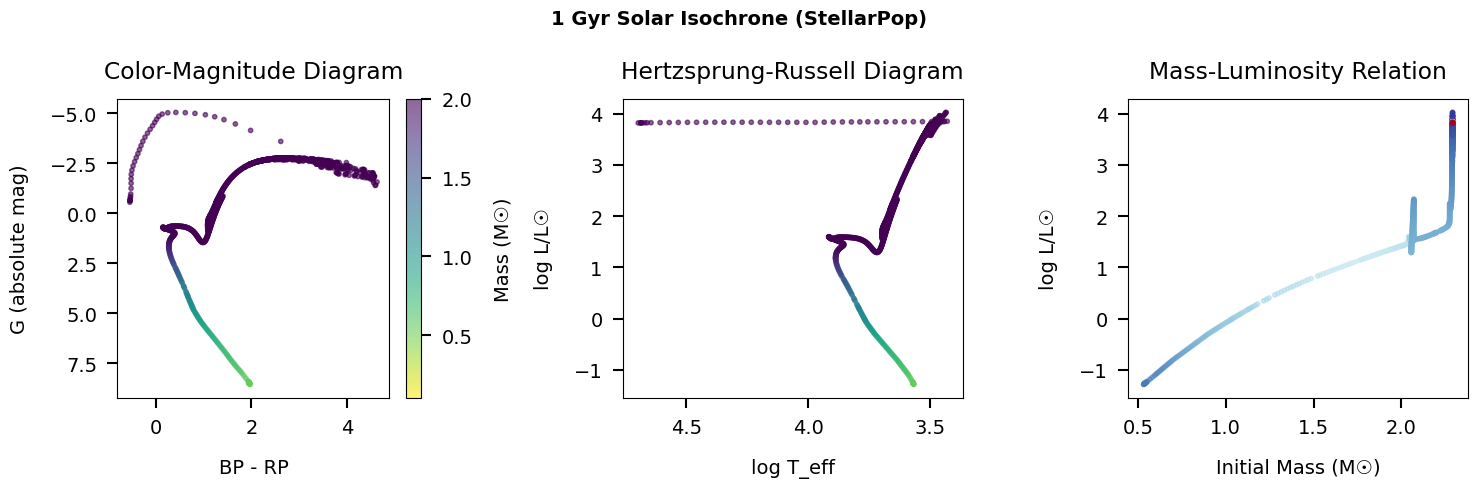

In [7]:
# Visualize the isochrone
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Gaia CMD
ax = axes[0]
bp_rp = mags[valid, 1] - mags[valid, 2]
g_mag = mags[valid, 0]
mini_valid = params['mini'][valid]

scatter = ax.scatter(bp_rp, g_mag, c=mini_valid, s=10,
                    cmap='viridis_r', vmin=0.1, vmax=2.0, alpha=0.6)
ax.set_xlabel('BP - RP')
ax.set_ylabel('G (absolute mag)')
ax.set_title('Color-Magnitude Diagram')
ax.invert_yaxis()
plt.colorbar(scatter, ax=ax, label='Mass (M☉)')

# Panel 2: HRD (with validity filter)
ax = axes[1]
hrd_valid = valid & np.isfinite(params['logt']) & np.isfinite(params['logl'])
ax.scatter(params['logt'][hrd_valid], params['logl'][hrd_valid],
          c=params['mini'][hrd_valid], s=10,
          cmap='viridis_r', vmin=0.1, vmax=2.0, alpha=0.6)
ax.set_xlabel('log T_eff')
ax.set_ylabel('log L/L☉')
ax.set_title('Hertzsprung-Russell Diagram')
ax.invert_xaxis()

# Panel 3: Mass-Luminosity relation
ax = axes[2]
ax.scatter(params['mini'][hrd_valid], params['logl'][hrd_valid],
          c=params['logt'][hrd_valid], s=10,
          cmap='RdYlBu_r', alpha=0.6)
ax.set_xlabel('Initial Mass (M☉)')
ax.set_ylabel('log L/L☉')
ax.set_title('Mass-Luminosity Relation')

plt.suptitle('1 Gyr Solar Isochrone (StellarPop)', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'stellarpop_isochrone')
plt.show()

## Section 3: Isochrone Age Sequences

Stellar populations evolve with time as stars leave the main sequence.
Let's explore how isochrones change with age.

### Age Effects

- **Main sequence turnoff** moves to lower masses with age
- **Red giant branch** develops for older populations
- **Horizontal branch** appears in old, metal-poor populations
- **Color distribution** becomes redder with age

Generating age sequence...
  4 Myr: 1621 valid points


  10 Myr: 1999 valid points
  100 Myr: 2000 valid points
  1 Gyr: 1865 valid points
  3 Gyr: 1780 valid points
  10 Gyr: 1683 valid points


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_02/age_sequences.png


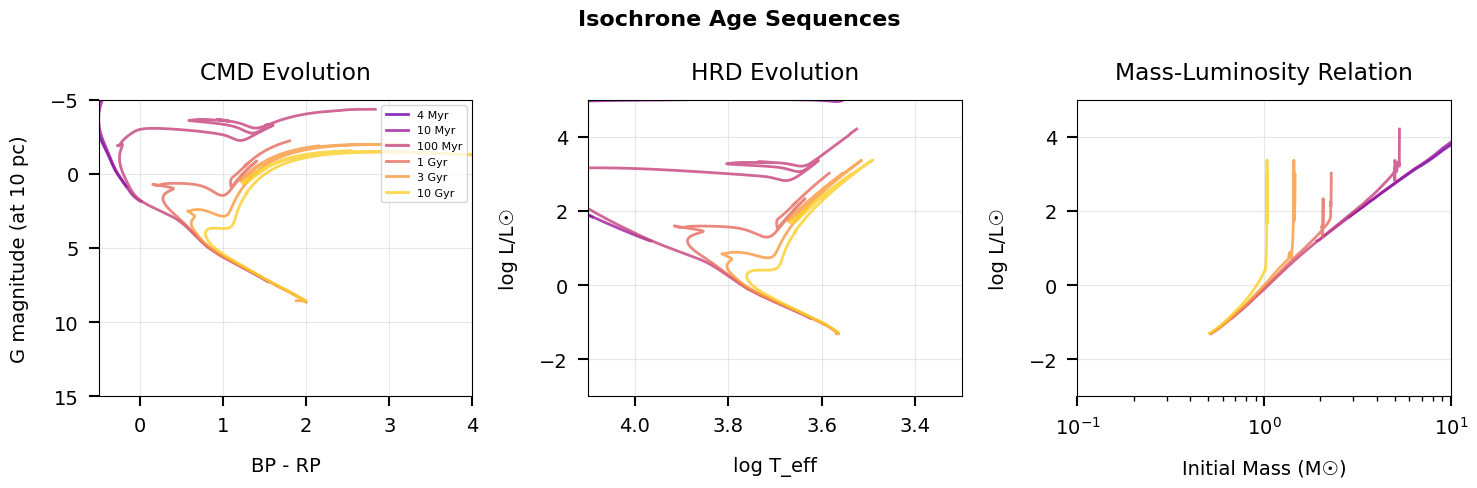


Age sequence effects demonstrated


In [8]:
# Create age sequence plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age grid (log years)
ages = [6.6, 7.0, 8.0, 9.0, 9.5, 10.0]  # 4 Myr to 10 Gyr
age_labels = ['4 Myr', '10 Myr', '100 Myr', '1 Gyr', '3 Gyr', '10 Gyr']
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(ages)))

# Fixed metallicity
feh, afe = 0.0, 0.0
eep_grid = np.linspace(202, 808, 2000)

print("Generating age sequence...")

for loga, label, color in zip(ages, age_labels, colors):
    # Generate isochrone stellar parameters
    params_arr = iso.get_predictions(feh=feh, afe=afe, loga=loga, eep=eep_grid)
    params = {label: params_arr[:, i] for i, label in enumerate(iso.predictions)}
    
    # Get magnitudes using StellarPop
    mags, _, _ = pop.get_seds(feh=feh, afe=afe, loga=loga, eep=eep_grid, 
                               dist=10.0, binary_fraction=0.0)
    
    # Valid points
    valid = np.isfinite(params['mini']) & np.isfinite(mags[:, 0])
    
    # Panel 1: CMD
    bp_rp = mags[valid, 1] - mags[valid, 2]
    g_mag = mags[valid, 0]
    axes[0].plot(bp_rp, g_mag, color=color, lw=2, alpha=0.8, label=label)
    
    # Panel 2: HRD
    axes[1].plot(params['logt'][valid], params['logl'][valid],
                   color=color, lw=2, alpha=0.8)
    
    # Panel 3: Mass-Luminosity
    axes[2].plot(params['mini'][valid], params['logl'][valid],
                   color=color, lw=2, alpha=0.8)
    
    print(f"  {label}: {valid.sum()} valid points")

# Format all plots
axes[0].set_xlabel('BP - RP')
axes[0].set_ylabel('G magnitude (at 10 pc)')
axes[0].set_title('CMD Evolution')
axes[0].invert_yaxis()
axes[0].set_xlim(-0.5, 4.0)
axes[0].set_ylim(15, -5)
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('log T_eff')
axes[1].set_ylabel('log L/L☉')
axes[1].set_title('HRD Evolution')
axes[1].invert_xaxis()
axes[1].set_xlim(4.1, 3.3)
axes[1].set_ylim(-3, 5)
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Initial Mass (M☉)')
axes[2].set_ylabel('log L/L☉')
axes[2].set_title('Mass-Luminosity Relation')
axes[2].set_xscale('log')
axes[2].set_xlim(0.1, 10)
axes[2].set_ylim(-3, 5)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Isochrone Age Sequences', fontsize=16, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'age_sequences')
plt.show()

print("\nAge sequence effects demonstrated")

## Section 4: Metallicity Effects on Stellar Populations

Metallicity profoundly affects stellar populations, changing their colors, luminosities, and evolutionary timescales.

### Metallicity Effects

- **Metal-poor stars** are bluer and hotter at fixed mass
- **RGB position** is sensitive to metallicity
- **Main sequence width** increases with metallicity spread
- **Galactic components** have distinct metallicity distributions

Generating metallicity sequence...
  [Fe/H] = -2.0: 1728 valid points


  [Fe/H] = -1.0: 1741 valid points
  [Fe/H] = -0.5: 1754 valid points
  [Fe/H] = +0.0: 1829 valid points
  [Fe/H] = +0.3: 1775 valid points


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_02/metallicity_populations.png


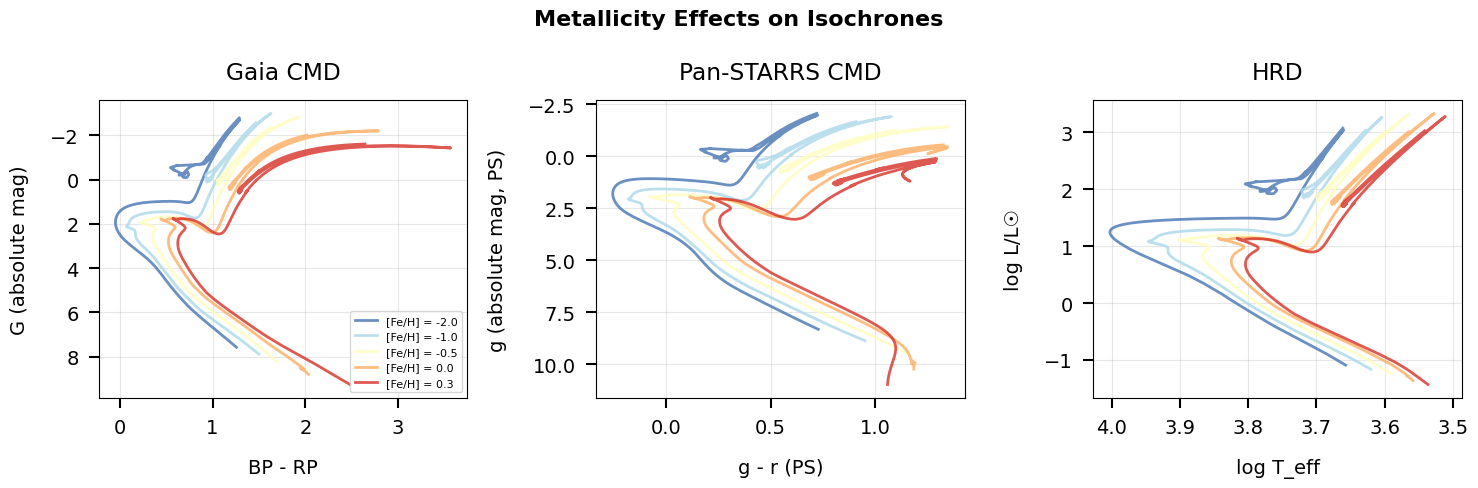


Metallicity effects demonstrated


In [9]:
# Create metallicity comparison plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Metallicity grid
feh_values = [-2.0, -1.0, -0.5, 0.0, 0.3]
colors = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(feh_values)))

# Fixed age, use absolute magnitudes (10 pc)
loga, afe = 9.3, 0.0  # 2 Gyr
eep_grid = np.linspace(202, 808, 2000)

print("Generating metallicity sequence...")

for feh, color in zip(feh_values, colors):
    # Generate isochrone
    params_arr = iso.get_predictions(feh=feh, afe=afe, loga=loga, eep=eep_grid)
    params = {label: params_arr[:, i] for i, label in enumerate(iso.predictions)}
    
    # Get magnitudes at 10 pc (absolute)
    mags, _, _ = pop.get_seds(feh=feh, afe=afe, loga=loga, eep=eep_grid, 
                              dist=10.0, binary_fraction=0.0)
    
    # Valid points
    valid = np.isfinite(params['mini']) & np.all(np.isfinite(mags), axis=1)
    
    # Panel 1: Gaia CMD
    bp_rp = mags[valid, 1] - mags[valid, 2]
    g_mag = mags[valid, 0]
    axes[0].plot(bp_rp, g_mag, color=color, lw=2, alpha=0.8,
                   label=f'[Fe/H] = {feh:.1f}')
    
    # Panel 2: PS CMD
    g_ps = mags[valid, 3]  # PS g
    r_ps = mags[valid, 4]  # PS r
    axes[1].plot(g_ps - r_ps, g_ps, color=color, lw=2, alpha=0.8)
    
    # Panel 3: HRD
    hrd_valid = valid & np.isfinite(params['logt']) & np.isfinite(params['logl'])
    axes[2].plot(params['logt'][hrd_valid], params['logl'][hrd_valid],
                   color=color, lw=2, alpha=0.8)
    
    print(f"  [Fe/H] = {feh:+.1f}: {valid.sum()} valid points")

# Format plots
axes[0].set_xlabel('BP - RP')
axes[0].set_ylabel('G (absolute mag)')
axes[0].set_title('Gaia CMD')
axes[0].invert_yaxis()
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('g - r (PS)')
axes[1].set_ylabel('g (absolute mag, PS)')
axes[1].set_title('Pan-STARRS CMD')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('log T_eff')
axes[2].set_ylabel('log L/L☉')
axes[2].set_title('HRD')
axes[2].invert_xaxis()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Metallicity Effects on Isochrones', fontsize=16, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'metallicity_populations')
plt.show()

print("\nMetallicity effects demonstrated")

## Section 5: IMF Sampling and Mass Functions

The Initial Mass Function (IMF) determines the distribution of stellar masses in a population.

### Common IMFs

- **Salpeter (1955)**: Single power law with α = 2.35
- **Kroupa (2001)**: Broken power law with shallower slope at low masses
- **Chabrier (2003)**: Log-normal at low masses, power law at high masses

The choice of IMF significantly affects:
- Number of low-mass stars
- Total stellar mass
- Mass-to-light ratio
- Chemical enrichment rates

IMF comparison:
  Kroupa: Broken power law (α₁=1.3, α₂=2.3)
  Salpeter: Single power law (α=2.35)
  Modified: Steeper high-mass slope (α₂=2.7)


  Kroupa: 50% of mass in stars > 0.27 M☉
  Salpeter: 50% of mass in stars > 0.17 M☉


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_02/imf_sampling.png


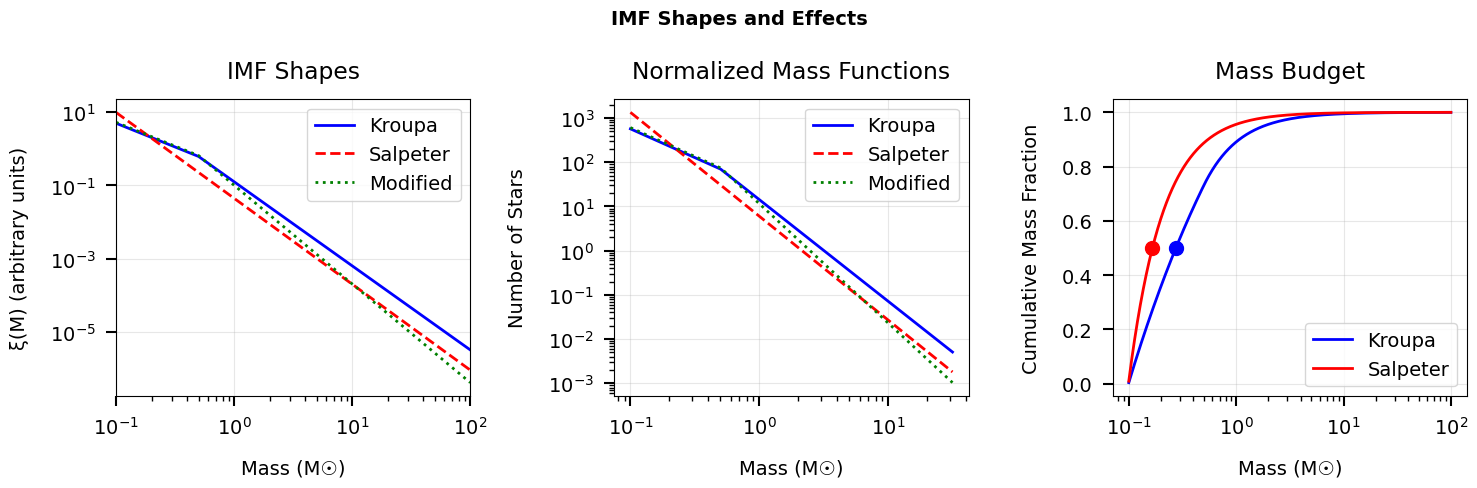

In [10]:
from brutus.priors.stellar import logp_imf

# Create IMF comparison plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Different IMF shapes
ax = axes[0]
mass_grid = np.logspace(-1, 2, 1000)

# Kroupa IMF (broken power law)
kroupa_lnp = logp_imf(mass_grid, alpha_low=1.3, alpha_high=2.3, mass_break=0.5)
ax.plot(mass_grid, np.exp(kroupa_lnp), 'b-', lw=2, label='Kroupa')

# Salpeter IMF (single power law)
salpeter_lnp = logp_imf(mass_grid, alpha_low=2.35, alpha_high=2.35, mass_break=0.5)
ax.plot(mass_grid, np.exp(salpeter_lnp), 'r--', lw=2, label='Salpeter')

# Modified Kroupa (steeper high mass slope)
modified_lnp = logp_imf(mass_grid, alpha_low=1.3, alpha_high=2.7, mass_break=0.5)
ax.plot(mass_grid, np.exp(modified_lnp), 'g:', lw=2, label='Modified')

ax.set_xlabel('Mass (M☉)')
ax.set_ylabel('ξ(M) (arbitrary units)')
ax.set_title('IMF Shapes')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.1, 100)
ax.legend()
ax.grid(True, alpha=0.3)

print("IMF comparison:")
print("  Kroupa: Broken power law (α₁=1.3, α₂=2.3)")
print("  Salpeter: Single power law (α=2.35)")
print("  Modified: Steeper high-mass slope (α₂=2.7)")

# Panel 2: Normalized mass distributions
ax = axes[1]

for (alpha_low, alpha_high, label), color, ls in [
    ((1.3, 2.3, 'Kroupa'), 'blue', '-'),
    ((2.35, 2.35, 'Salpeter'), 'red', '--'),
    ((1.3, 2.7, 'Modified'), 'green', ':')]:
    
    mass_test = np.logspace(-1, 1.5, 1000)
    pdf = np.exp(logp_imf(mass_test, alpha_low=alpha_low, alpha_high=alpha_high))
    pdf = pdf / np.trapz(pdf, mass_test)  # Normalize
    ax.plot(mass_test, pdf * 100, color=color, ls=ls, lw=2, label=label)

ax.set_xlabel('Mass (M☉)')
ax.set_ylabel('Number of Stars')
ax.set_title('Normalized Mass Functions')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: Cumulative mass fraction
ax = axes[2]

mass_test = np.logspace(-1, 2, 1000)
for (alpha_low, alpha_high, label), color in [
    ((1.3, 2.3, 'Kroupa'), 'blue'),
    ((2.35, 2.35, 'Salpeter'), 'red')]:
    
    pdf = np.exp(logp_imf(mass_test, alpha_low=alpha_low, alpha_high=alpha_high))
    # Weight by mass for mass fraction
    mass_weighted = pdf * mass_test
    cumulative_mass = np.cumsum(mass_weighted) / np.sum(mass_weighted)
    
    ax.plot(mass_test, cumulative_mass, color=color, lw=2, label=label)
    
    # Mark 50% mass point
    idx_50 = np.argmin(np.abs(cumulative_mass - 0.5))
    ax.scatter(mass_test[idx_50], 0.5, color=color, s=100, zorder=5)
    print(f"  {label}: 50% of mass in stars > {mass_test[idx_50]:.2f} M☉")

ax.set_xlabel('Mass (M☉)')
ax.set_ylabel('Cumulative Mass Fraction')
ax.set_title('Mass Budget')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('IMF Shapes and Effects', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'imf_sampling')
plt.show()

## Section 6: Isochrone Comparisons Across Cluster Types

Different stellar environments have distinct ages, metallicities, and
alpha enhancements. Let's compare isochrones for three representative
cluster types to see how these parameters affect the CMD and HRD.

In [11]:
# Extended filter set for multi-wavelength comparison
filt_full = filters.gaia + filters.ps[:3] + filters.tmass
pop_full = StellarPop(isochrone=iso, filters=filt_full, nnfile=nnfile, verbose=False)
print(f"Using extended filter set: {', '.join(filt_full)}")

# Generate isochrones for three different cluster types
# Use absolute magnitudes (dist=10 pc) so all are on the same scale
print("\nGenerating isochrones for different cluster types...\n")

# Cluster 1: Young open cluster (Pleiades-like)
print("  Young (100 Myr, solar)...")
mags1, params1, _ = pop_full.get_seds(
    feh=0.0, afe=0.0, loga=8.0,  # 100 Myr
    av=0.0, rv=3.32, dist=10.0,   # absolute magnitudes
    binary_fraction=0.0
)
valid1 = np.all(np.isfinite(mags1), axis=1)
print(f"    {valid1.sum()} valid EEP points")

# Cluster 2: Intermediate age (Hyades-like)
print("  Intermediate (625 Myr, slightly metal-rich)...")
mags2, params2, _ = pop_full.get_seds(
    feh=0.15, afe=0.0, loga=8.8,  # 625 Myr
    av=0.0, rv=3.32, dist=10.0,
    binary_fraction=0.0
)
valid2 = np.all(np.isfinite(mags2), axis=1)
print(f"    {valid2.sum()} valid EEP points")

# Cluster 3: Old globular cluster
# Note: We use afe=0.0 because the C3K neural network does not cover
# alpha-enhanced models. Real GCs are typically alpha-enhanced ([a/Fe]~0.3),
# but the NN returns NaN for any afe > 0.
print("  Old globular (12 Gyr, metal-poor)...")
mags3, params3, _ = pop_full.get_seds(
    feh=-1.5, afe=0.0, loga=10.08,  # 12 Gyr
    av=0.0, rv=3.32, dist=10.0,
    binary_fraction=0.0
)
valid3 = np.all(np.isfinite(mags3), axis=1)
print(f"    {valid3.sum()} valid EEP points")

Using extended filter set: Gaia_G_MAW, Gaia_BP_MAWf, Gaia_RP_MAW, PS_g, PS_r, PS_i, 2MASS_J, 2MASS_H, 2MASS_Ks

Generating isochrones for different cluster types...

  Young (100 Myr, solar)...
    1315 valid EEP points
  Intermediate (625 Myr, slightly metal-rich)...
    1273 valid EEP points
  Old globular (12 Gyr, metal-poor)...
    1199 valid EEP points


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_02/cluster_isochrones.png


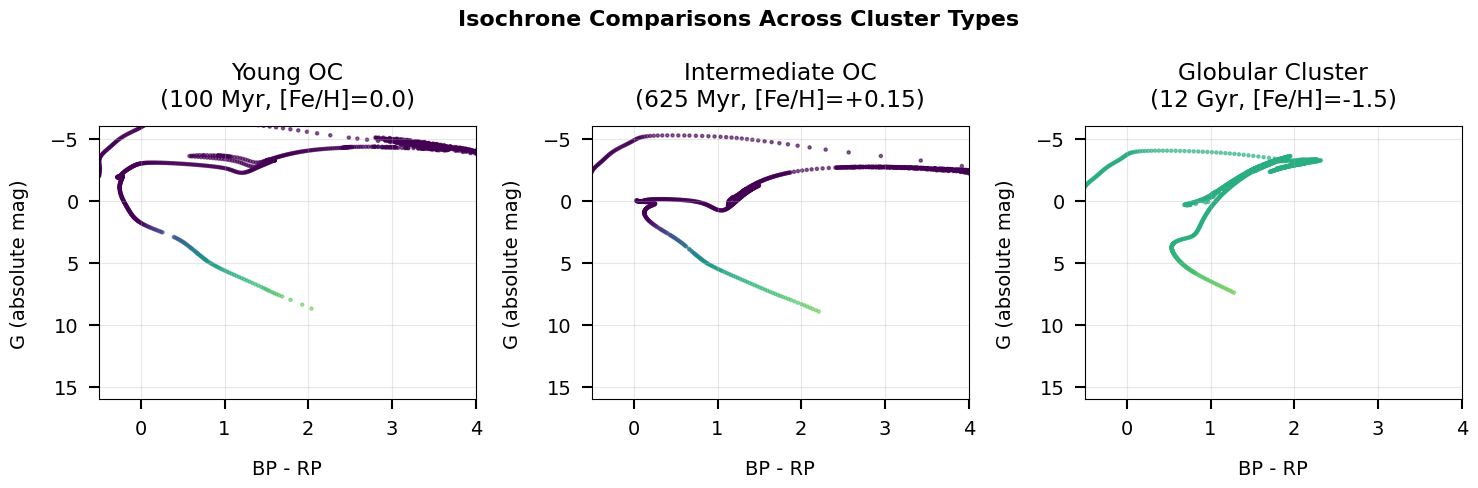


Isochrone comparisons demonstrated
  Total valid EEP points: 3787


In [12]:
# Create isochrone comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Top row: Individual isochrone CMDs colored by mass
isochrones = [
    (mags1, params1, valid1, 'Young OC\n(100 Myr, [Fe/H]=0.0)'),
    (mags2, params2, valid2, 'Intermediate OC\n(625 Myr, [Fe/H]=+0.15)'),
    (mags3, params3, valid3, 'Globular Cluster\n(12 Gyr, [Fe/H]=-1.5)'),
]

# Common axis limits for fair comparison
common_xlim = (-0.5, 4.0)
common_ylim = (16, -6)

for idx, (mags, params, valid, title) in enumerate(isochrones):
    ax = axes[idx]
    
    bp_rp = mags[valid, 1] - mags[valid, 2]
    g_mag = mags[valid, 0]
    
    if np.any(valid):
        scatter = ax.scatter(bp_rp, g_mag,
                           c=params['mini'][valid],
                           s=5, cmap='viridis_r', vmin=0.1, vmax=2.0, alpha=0.6)
    else:
        ax.text(0.5, 0.5, 'No valid\nphotometry', transform=ax.transAxes,
                ha='center', va='center', fontsize=12, color='gray')
    
    ax.set_xlabel('BP - RP')
    ax.set_ylabel('G (absolute mag)')
    ax.set_title(title)
    ax.set_xlim(common_xlim)
    ax.set_ylim(common_ylim)
    ax.grid(True, alpha=0.3)

plt.suptitle('Isochrone Comparisons Across Cluster Types', fontsize=16, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'cluster_isochrones')
plt.show()

print("\nIsochrone comparisons demonstrated")
print(f"  Total valid EEP points: {valid1.sum() + valid2.sum() + valid3.sum()}")

  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_02/ps1_luminosity_function.png


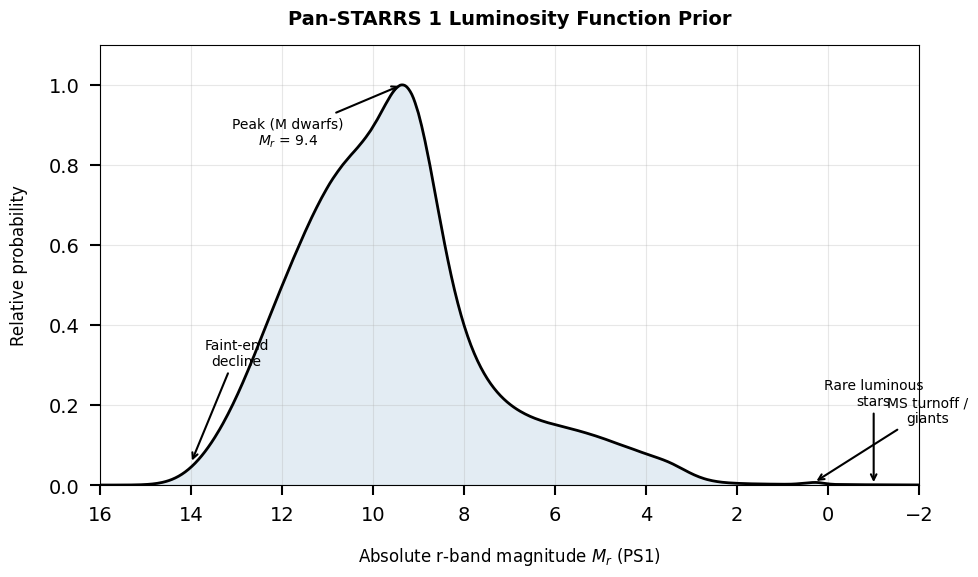

Evaluated PS1 LF prior over Mr = [-2, 16]
  Peak at Mr = 9.4
  log-prior range: [-18.5, -3.9]


In [13]:
from brutus.priors.stellar import logp_ps1_luminosity_function

# Create an array of absolute r-band magnitudes spanning the full range
Mr = np.linspace(-2, 16, 500)

# Evaluate the log-prior
logp = logp_ps1_luminosity_function(Mr)

# Convert to relative probability for plotting
prob = np.exp(logp - logp.max())  # normalize so peak = 1

# Plot the PS1 luminosity function
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(Mr, prob, 'k-', lw=2)
ax.fill_between(Mr, prob, alpha=0.15, color='steelblue')

# Annotate key features
# Peak at faint end (M dwarfs, Mr ~ 9-10)
peak_idx = np.argmax(prob)
ax.annotate(f'Peak (M dwarfs)\n$M_r$ = {Mr[peak_idx]:.1f}',
            xy=(Mr[peak_idx], prob[peak_idx]),
            xytext=(Mr[peak_idx] + 2.5, prob[peak_idx] - 0.15),
            fontsize=10, ha='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# MS turnoff bump (Mr ~ 0-1, local maximum from evolved stars)
turnoff_region = (Mr > -1) & (Mr < 2)
turnoff_idx = np.where(turnoff_region)[0][np.argmax(prob[turnoff_region])]
ax.annotate('MS turnoff /\ngiants',
            xy=(Mr[turnoff_idx], prob[turnoff_idx]),
            xytext=(Mr[turnoff_idx] - 2.5, prob[turnoff_idx] + 0.15),
            fontsize=10, ha='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Faint end decline
ax.annotate('Faint-end\ndecline',
            xy=(14, prob[Mr > 13.9][0]),
            xytext=(13, 0.3),
            fontsize=10, ha='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Bright end (rare luminous stars)
ax.annotate('Rare luminous\nstars',
            xy=(-1, prob[Mr < -0.9][0]),
            xytext=(-1, 0.2),
            fontsize=10, ha='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax.set_xlabel('Absolute r-band magnitude $M_r$ (PS1)', fontsize=12)
ax.set_ylabel('Relative probability', fontsize=12)
ax.set_title('Pan-STARRS 1 Luminosity Function Prior', fontsize=14, fontweight='bold')
ax.set_xlim(Mr.max(), Mr.min())  # Reversed: bright on right, faint on left
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3)

save_figure(fig, 'ps1_luminosity_function')
plt.show()

print(f"Evaluated PS1 LF prior over Mr = [{Mr.min():.0f}, {Mr.max():.0f}]")
print(f"  Peak at Mr = {Mr[peak_idx]:.1f}")
print(f"  log-prior range: [{logp.min():.1f}, {logp.max():.1f}]")

In [14]:
# Verify output shapes and basic properties
assert Mr.shape == (500,), f"Expected Mr shape (500,), got {Mr.shape}"
assert logp.shape == Mr.shape, f"Expected logp shape {Mr.shape}, got {logp.shape}"
assert np.all(np.isfinite(logp)), "All log-prior values should be finite"
assert np.all(logp < 0), "All log-prior values should be negative (log of probability < 1)"
assert prob.max() == 1.0, "Peak relative probability should be 1.0 after normalization"

# Verify the peak is in the expected range (faint M dwarfs, Mr ~ 8-11)
assert 8 < Mr[peak_idx] < 11, f"Expected peak near Mr ~ 9-10, got Mr = {Mr[peak_idx]:.1f}"

# Verify monotonic decline at the faint end (Mr > 12)
faint_mask = Mr > 12
assert np.all(np.diff(logp[faint_mask]) < 0), "LF should decline at faint end (Mr > 12)"

print("All assertions passed.")
print(f"  Mr array shape: {Mr.shape}")
print(f"  logp array shape: {logp.shape}")
print(f"  Peak location: Mr = {Mr[peak_idx]:.1f}")
print(f"  Prob range: [{prob.min():.6f}, {prob.max():.1f}]")

All assertions passed.
  Mr array shape: (500,)
  logp array shape: (500,)
  Peak location: Mr = 9.4
  Prob range: [0.000000, 1.0]


## Summary and Key Takeaways

This tutorial has covered stellar population modeling in brutus:

### Key Classes

1. **Isochrone**: Models coeval stellar populations
   - Interpolates MIST isochrone tables
   - Returns stellar parameters for populations of given age/metallicity
   - Covers full range of stellar masses at each age

2. **StellarPop**: Generates synthetic populations with photometry
   - Combines Isochrone with neural network photometry
   - Handles binary populations
   - Applies extinction and distance effects
   - Enables realistic cluster simulations

### Physical Effects

- **Age**: Determines turnoff mass and RGB properties
- **Metallicity**: Affects colors, luminosities, and evolution
- **IMF**: Controls the mass distribution and low-mass star counts
- **Binaries**: Create broader sequences and affect cluster dynamics

### Applications

- Star cluster analysis and fitting
- Stellar population synthesis
- Galactic archaeology studies
- Calibration of stellar parameters

### Next Steps

- **Tutorial 3**: Model Grids and Performance Optimization
- **Tutorial 4**: Galactic Priors and Population Synthesis
- **Tutorial 5**: Fitting Individual Sources with BruteForce
- **Tutorial 6**: Cluster Analysis and Bayesian Inference

In [15]:
print("Tutorial 2 Complete!")
print("="*60)
print("\nGenerated plots:")
for plot_file in sorted(plots_dir.glob('*.png')):
    print(f"  - {plot_file.name}")

Tutorial 2 Complete!

Generated plots:
  - age_sequences.png
  - cluster_isochrones.png
  - imf_sampling.png
  - metallicity_populations.png
  - ps1_luminosity_function.png
  - stellarpop_isochrone.png
